In [1]:
# Path + packaging
import sys  # no installation needed
from pathlib import Path  # no installation needed

SRC_DIR = Path(r"C:\Users\quantbase\Desktop\SyStrat\src")
PKG_DIR = SRC_DIR / "syslib"
PKG_DIR.mkdir(parents=True, exist_ok=True)
(PKG_DIR / "__init__.py").touch(exist_ok=True)  # ensure it's importable

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("sys.path OK:", SRC_DIR in map(Path, map(str, sys.path)))


sys.path OK: True


In [2]:
from pathlib import Path
import importlib, pandas as pd
import datetime as date
from datetime import date
import syslib.wp_core as wp_core
from syslib.wp_bt_legacy import LegacyConfig, run_legacy_total
import syslib.wp_bt_legacy as wpbt
import matplotlib.pyplot as plt
importlib.reload(wpbt)  # ensure the edits above are loaded

<module 'syslib.wp_bt_legacy' from 'C:\\Users\\quantbase\\Desktop\\SyStrat\\src\\syslib\\wp_bt_legacy.py'>

In [3]:
RUN_DATE = date.today().strftime("%d-%m-%Y") #"30-10-2025"
BASE = Path(r"C:\Users\quantbase\Desktop\SyStrat") / RUN_DATE
FIGDIR = BASE / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

In [4]:
symbols = ['BTC-USD','ETH-USD','BNB-USD','XRP-USD','ADA-USD','LINK-USD','SOL-USD']
portw   = [0.23, 0.078, 0.078, 0.078, 0.078, 0.078, 0.078]

In [5]:
# Portfolio weights (example; use yours)
weights = {
    "BTC-USD":0.23, "ETH-USD":0.078, "BNB-USD":0.078,
    "XRP-USD":0.078, "ADA-USD":0.078, "LINK-USD":0.078, "SOL-USD":0.078
}

In [6]:
#EWMA Plot---------------

In [6]:
from pathlib import Path
import importlib, pandas as pd

import syslib.wp_bt_legacy as bt
from syslib.wp_bt_legacy import LegacyConfig, run_legacy_total
importlib.reload(bt)

<module 'syslib.wp_bt_legacy' from 'C:\\Users\\quantbase\\Desktop\\SyStrat\\src\\syslib\\wp_bt_legacy.py'>

In [7]:
cfg = LegacyConfig(
    start = pd.Timestamp.today().normalize() - pd.Timedelta(days=365*2),
    end   = pd.Timestamp.today().normalize(),
    notional=50_000.0, leverage=2.5, risk_fraction=0.02,
    stdev_window=55, annualize_factor=19.0,
    blend_weight=0.7, lookahead_mean_horizon=54,
    strict_mimic=True, legacy_sign=+1.0, normalize_to_zero=True,
)

In [8]:
cum_ewma_full = run_legacy_total(
    weights, prices=None, cfg=cfg, baseline="zero",
    vol_provider="ewma_legacy",
    provider_kwargs={"tail_policy": "ffill"},   # extend EWMA to the end
)

Text(0, 0.5, 'Cumulative PnL')

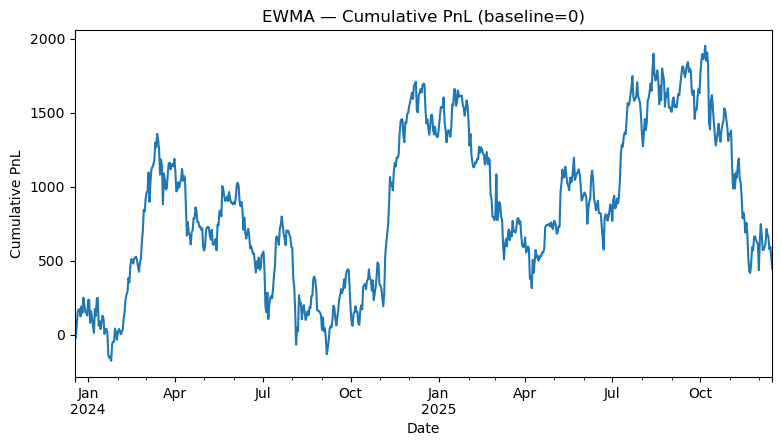

In [9]:
# Plot cumulative PnL (single line)
ax = cum_ewma_full.plot(figsize=(9,4.5), title="EWMA — Cumulative PnL (baseline=0)")
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative PnL")

Text(0, 0.5, 'Daily PnL')

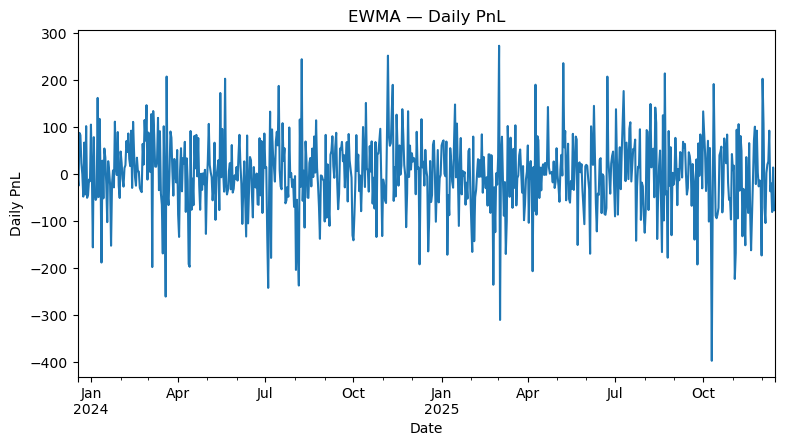

In [10]:
# Plot daily PnL (returns = diff of cumulative)
ret_ewma = cum_ewma_full.diff().fillna(0.0)
ax2 = ret_ewma.plot(figsize=(9,4.5), title="EWMA — Daily PnL")
ax2.set_xlabel("Date"); ax2.set_ylabel("Daily PnL")

Text(0, 0.5, 'Equity ($)')

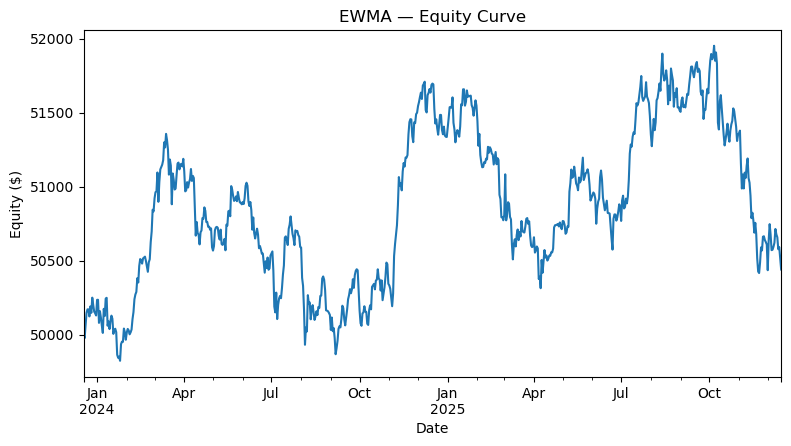

In [11]:
equity_ewma = (cfg.notional + cum_ewma_full).rename("EWMA Equity")
ax = equity_ewma.plot(figsize=(9,4.5), title="EWMA — Equity Curve")
ax.set_xlabel("Date"); ax.set_ylabel("Equity ($)")


In [12]:
#ML Only------------

In [13]:
# 1) build rowmap for TEST (same per-ticker split logic you used before)
from pathlib import Path
import pandas as pd, numpy as np

#BASE = Path(r"C:\Users\quantbase\Desktop\SyStrat") / "27-10-2025"
Xy = pd.read_parquet(BASE / "data_int/ml/features_raw_long.parquet").sort_values(["ticker","date"]).reset_index(drop=True)

rows = []
for tkr, g in Xy.groupby("ticker", sort=True):
    n = len(g)
    i1 = int(np.floor(0.40*n))
    i2 = i1 + int(np.floor(0.35*n))
    rows.append(g.iloc[i2:][["date","ticker"]])      # TEST slice per ticker
rowmap = pd.concat(rows, ignore_index=True)
rowmap.to_parquet(BASE / "data_int/ml/rowmap_test_k10.parquet")
print("Saved rowmap:", BASE / "data_int/ml/rowmap_test_k10.parquet")

Saved rowmap: C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\ml\rowmap_test_k10.parquet


In [14]:
from pathlib import Path
import pandas as pd, numpy as np

#BASE = Path(r"C:\Users\quantbase\Desktop\SyStrat") / "24-10-2025"
K = 10

p_preds = BASE / f"data_int/ml/preds_test_k{K}.parquet"
p_row   = BASE / f"data_int/ml/rowmap_test_k{K}.parquet"      # the TEST (date,ticker) map
outdir  = BASE / f"data_int/ml/preds_test_k{K}"
outdir.mkdir(parents=True, exist_ok=True)

dfp  = pd.read_parquet(p_preds).reset_index(drop=True)
row  = pd.read_parquet(p_row)[["date","ticker"]].reset_index(drop=True)

assert len(dfp) == len(row), "rowmap and preds length mismatch"

df = pd.concat([row, dfp], axis=1)  # attach actual TEST dates & tickers

# write per-ticker WITH date
cols = [c for c in df.columns if c in ("date","ticker","y_true","pred","pred_en","pred_gbm","pred_xgb")]
for tkr, g in df.groupby("ticker", sort=True):
    g[cols].to_parquet(outdir / f"{tkr}.parquet")

# quick sanity: make sure each ticker file ends near the price's recent dates
last_dates = df.groupby("ticker")["date"].max().sort_index()
print("Last TEST date per ticker:\n", last_dates)

Last TEST date per ticker:
 ticker
ADA-USD    2025-12-05
BNB-USD    2025-12-05
BTC-USD    2025-12-05
ETH-USD    2025-12-05
LINK-USD   2025-12-05
SOL-USD    2025-12-05
XRP-USD    2025-12-05
Name: date, dtype: datetime64[ns]


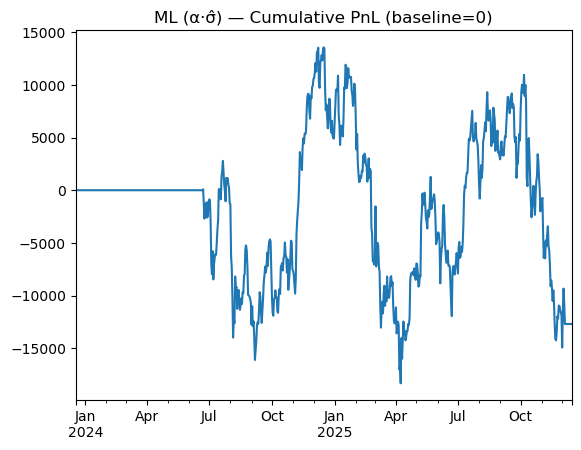

In [15]:
cum_ml = run_legacy_total(
    weights, prices=None, cfg=cfg, baseline="zero",
    vol_provider="ml_manifest",
    provider_kwargs={
        "base_dir": BASE, "k_label": K, "model_tag": "gbm",
        "per_ticker_dir": BASE / f"data_int/ml/preds_test_k{K}",
        "pred_model_col": "pred_xgb",  # or 'pred_en'
    },
)
cum_ml.plot(title="ML (α·σ̂) — Cumulative PnL (baseline=0)");


In [16]:
cfg = LegacyConfig(
    start = pd.Timestamp.today().normalize() - pd.Timedelta(days=365*2),
    end   = pd.Timestamp.today().normalize(),
    notional=50_000.0, leverage=2.5, risk_fraction=0.02/19,
    stdev_window=55, annualize_factor=19.0,
    blend_weight=0.7, lookahead_mean_horizon=54,
    strict_mimic=True, legacy_sign=+1.0, normalize_to_zero=True,
)

In [17]:
# Option 1: single-file vector (no date/ticker cols) — works now
cum_ml = run_legacy_total(
    weights, prices=None, cfg=cfg, baseline="zero",
    vol_provider="ml_manifest",
    provider_kwargs={
        "base_dir": BASE,
        "k_label": 10,
        #"single_symbol": "BTC-USD",
        #"pred_model_col": "pred_gbm",  # or 'pred_en'
        # Option 2 (when ready): per-ticker parquet folder, then use:
        "per_ticker_dir": BASE / "data_int/ml/preds_test_k10",
    },
    save_pdf=str((BASE / "figures" / "ml_total_cumPnL.pdf").resolve()),
)

Text(0, 0.5, 'Cumulative PnL')

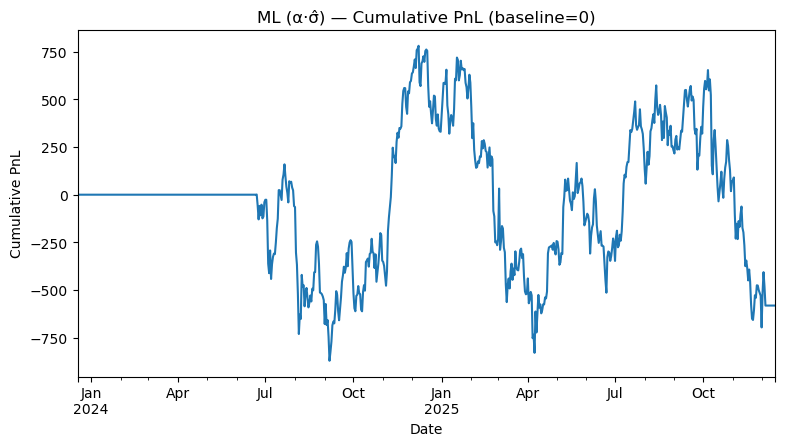

In [18]:
# Plot cumulative PnL (single line)
ax = cum_ml.plot(figsize=(9,4.5), title="ML (α·σ̂) — Cumulative PnL (baseline=0)")
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative PnL")

Text(0, 0.5, 'Daily PnL')

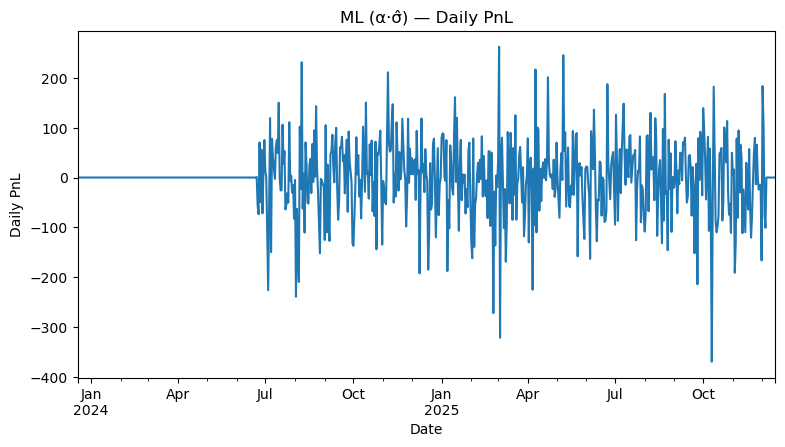

In [19]:
# Plot daily PnL (returns = diff of cumulative)
ret_ml = cum_ml.diff().fillna(0.0)
ax2 = ret_ml.plot(figsize=(9,4.5), title="ML (α·σ̂) — Daily PnL")
ax2.set_xlabel("Date"); ax2.set_ylabel("Daily PnL")

Text(0, 0.5, 'Equity ($)')

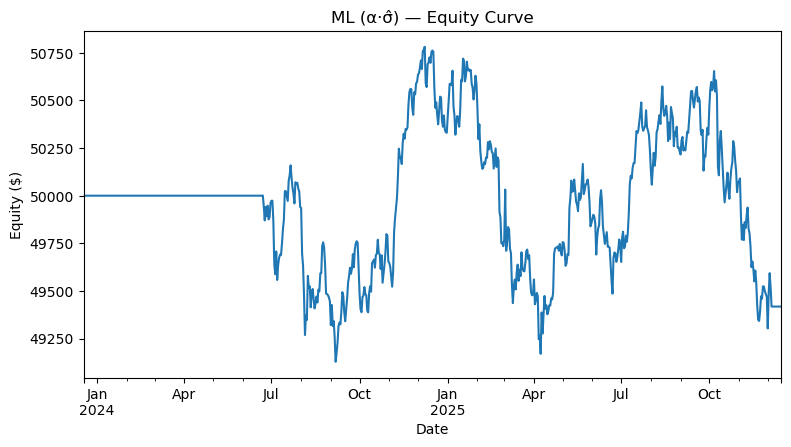

In [20]:
equity_ml = (cfg.notional + cum_ml).rename("ML Equity")
ax = equity_ml.plot(figsize=(9,4.5), title="ML (α·σ̂) — Equity Curve")
ax.set_xlabel("Date"); ax.set_ylabel("Equity ($)")


Text(0, 0.5, 'Equity ($)')

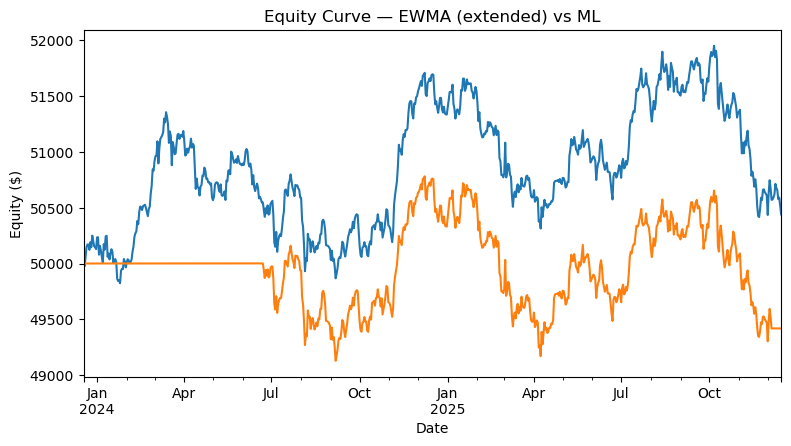

In [21]:
ax = (cfg.notional + cum_ewma_full).rename("EWMA (extended)").plot(
    figsize=(9,4.5), title="Equity Curve — EWMA (extended) vs ML"
)
(cfg.notional + cum_ml).rename("ML").plot(ax=ax)
ax.set_xlabel("Date"); ax.set_ylabel("Equity ($)")

In [33]:
#------save plots--------

In [33]:
# EWMA daily PnL
ret_ewma = cum_ewma_full.diff().fillna(0.0)
ax = ret_ewma.plot(figsize=(9,4.5), title="EWMA — Daily PnL")
ax.set_xlabel("Date"); ax.set_ylabel("Daily PnL")
ax.figure.tight_layout(); ax.figure.savefig(FIGDIR / "ewma_daily_pnl.pdf"); plt.close(ax.figure)

In [34]:
equity_ewma = (cfg.notional + cum_ewma_full).rename("EWMA Equity")
ax = equity_ewma.plot(figsize=(9,4.5), title="EWMA — Equity Curve")
ax.set_xlabel("Date"); ax.set_ylabel("Equity ($)")
ax.figure.tight_layout(); ax.figure.savefig(FIGDIR / "ewma_equity.pdf"); plt.close(ax.figure)


In [35]:
ret_ml = cum_ml.diff().fillna(0.0)
ax = ret_ml.plot(figsize=(9,4.5), title="ML (α·σ̂) — Daily PnL")
ax.set_xlabel("Date"); ax.set_ylabel("Daily PnL")
ax.figure.tight_layout(); ax.figure.savefig(FIGDIR / "ml_daily_pnl.pdf"); plt.close(ax.figure)

In [36]:
equity_ml = (cfg.notional + cum_ml).rename("ML Equity")
ax = equity_ml.plot(figsize=(9,4.5), title="ML (α·σ̂) — Equity Curve")
ax.set_xlabel("Date"); ax.set_ylabel("Equity ($)")
ax.figure.tight_layout(); ax.figure.savefig(FIGDIR / "ml_equity.pdf"); plt.close(ax.figure)

In [37]:
ax = equity_ewma.rename("EWMA").plot(figsize=(9,4.5), title="Equity Curve — EWMA vs ML")
equity_ml.rename("ML").plot(ax=ax)
ax.set_xlabel("Date"); ax.set_ylabel("Equity ($)")
ax.figure.tight_layout(); ax.figure.savefig(FIGDIR / "equity_overlay.pdf"); plt.close(ax.figure)

In [ ]:
#-------prev runs

In [ ]:
#---------- ML Estimate Backtest + Overlay Comparison